# Pixel-Based Cartpole Stabilisation — Results Plots

Three figures:
1. **Stabilisation performance vs. training trajectories** — median ± 5–95% error band and success rate from 100 trials.
2. **Luenberger gain matrix L heatmaps** — effective pixel-to-state mapping, one row per state variable.
3. **Time histories** — state trajectories, student estimate, and teacher-anticipated control.

Results that require simulation are cached in `fig1_sweep_cache.npz` and `fig3_rollout_cache.npz`.
Delete a cache file to force recomputation (Fig 1 takes ~20 min for the full sweep; Fig 3 takes ~30 s).

In [1]:
%matplotlib inline
import json, math, sys, time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from sklearn.linear_model import Ridge

SCRIPT_DIR = Path(".").resolve()
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

from nominal_cartpole import (
    NominalCartPoleParams, choose_cost_matrices, create_cartpole_env,
    linearize_nominal_cartpole, scale_cartpole_params, set_cartpole_state,
    solve_discrete_lqr, step_cartpole_env,
)
from teacher_policy import (
    extract_binary_pole_frame, load_observer_policy, pad_binary_frame_to_shape,
)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 11,
    "figure.dpi": 120,
})
print("Imports OK")

Imports OK


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────────────
OBSERVER_JSON     = SCRIPT_DIR / "hybrid_pixels_to_cartpole_observer_theta_blend_0p7.json"
COLLECTION_DIR    = SCRIPT_DIR.parent / "captures" / "collections" / "crop_padded_train_150demos"
FIG1_SWEEP_CACHE    = SCRIPT_DIR / "fig1_sweep_cache.npz"
FIG1_DEMO_CACHE_DIR = SCRIPT_DIR / "fig1_demo_features"   # per-demo feature cache (one npz per demo)
FIG3_ROLLOUT_CACHE  = SCRIPT_DIR / "fig3_rollout_cache.npz"

# ── Figure 1 — sweep ──────────────────────────────────────────────────────────────────
SWEEP_N_DEMOS        = list(range(10, 151, 10))  # training-set sizes: 10, 20, …, 150 [demos]
N_EVAL_TRIALS        = 100                        # initial conditions per observer    [trials]
EVAL_MAX_STEPS       = 250                        # rollout horizon                    [steps]  (= 4.17 s at 60 Hz)
PAPER_SUCCESS_STEPS  = 150                        # goal-zone deadline                 [steps]  (= 2.5 s at 60 Hz)
PAPER_SUCCESS_X_M    = 0.176                      # cart-position success threshold    [m]
PAPER_SUCCESS_THETA  = math.radians(2.0)          # pole-angle success threshold       [rad]  (= 2°)
RIDGE_ALPHA          = 0.1                        # Ridge regularisation strength      [dimensionless]
THETA_BLEND          = 0.7                        # pixel→θ blend weight               [dimensionless]
EVAL_SEED            = 0                          # RNG seed for IC sampling

# ── Figure 3 — rollout ────────────────────────────────────────────────────────────────────────────
FIG3_THETA0_DEG = 8.0   # initial pole angle  [deg]
FIG3_STEPS      = 300   # rollout length      [steps]  (= 5.0 s at 60 Hz)

# ── CartPole dynamics ─────────────────────────────────────────────────────────────────────────────
NOMINAL_PARAMS = NominalCartPoleParams(
    sample_time_s=1.0 / 60.0,    # control period        [s]   (= 60 Hz)
    max_force_n=10.0,             # actuator saturation   [N]
    control_penalty_r=1e-6,       # LQR input cost weight [dimensionless]
)
TRUE_PARAMS = scale_cartpole_params(
    NOMINAL_PARAMS,
    masspole_scale=1.1,            # true pole mass   = 1.1 × 0.1 kg = 0.11 kg
    half_pole_length_scale=0.9,    # true half-length = 0.9 × 0.5 m  = 0.45 m
)
A_nom, B_nom    = linearize_nominal_cartpole(NOMINAL_PARAMS)
Q_nom, R_nom    = choose_cost_matrices(NOMINAL_PARAMS)
K_teacher, _, _ = solve_discrete_lqr(A_nom, B_nom, Q_nom, R_nom)  # (1, 4)

print(f"Teacher gain  K = {K_teacher.flatten()}")
print(f"Observer JSON   : {OBSERVER_JSON.name}")
print(f"Collection      : {COLLECTION_DIR.name}")
print(f"Sweep sizes     : {SWEEP_N_DEMOS}")

Teacher gain  K = [ -31.47142974  -79.78914431 -970.80381643 -109.51126141]
Observer JSON   : hybrid_pixels_to_cartpole_observer_theta_blend_0p7.json
Collection      : crop_padded_train_150demos
Sweep sizes     : [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]


---
## Figure 1 — Stabilisation Performance vs. Training Trajectories

In [3]:
import gc

# ── Helper: discover max frame geometry across all demos ──────────────────────
def get_collection_geometry(demo_specs):
    target_h, target_w = 0, 0
    for spec in demo_specs:
        f = next(Path(spec["frame_dir"]).glob("frame_000000.png"), None)
        if f:
            img = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                target_h = max(target_h, img.shape[0])
                target_w = max(target_w, img.shape[1])
    return target_h, target_w


# ── Helper: load / cache a single demo's pixel features ───────────────────────
def load_demo_features(spec, target_h, target_w):
    """Load one demo from its per-demo npz cache; build and cache if missing."""
    FIG1_DEMO_CACHE_DIR.mkdir(exist_ok=True)
    demo_name  = Path(spec["frame_dir"]).name
    cache_file = FIG1_DEMO_CACHE_DIR / f"{demo_name}.npz"

    if cache_file.exists():
        c = np.load(cache_file)
        return c["X"], c["y_theta"]

    fd = Path(spec["frame_dir"])
    df = pd.read_csv(fd / "capture_trace.csv")
    X_rows, y_rows = [], []
    for _, row in df.iterrows():
        img = cv2.imread(str(fd / row["frame_filename"]), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        h, w      = img.shape
        pad_top   = max(0, target_h - h)
        pad_left  = max(0, (target_w - w) // 2)
        pad_right = max(0, target_w - w - pad_left)
        img_p = cv2.copyMakeBorder(img, pad_top, 0, pad_left, pad_right,
                                   cv2.BORDER_CONSTANT, value=0)
        X_rows.append((img_p.flatten() / 255.0).astype(np.float32))
        y_rows.append(float(row["true_pole_angle_rad"]))

    X = np.array(X_rows, dtype=np.float32)
    y = np.array(y_rows, dtype=np.float64)
    np.savez_compressed(cache_file, X=X, y_theta=y)
    return X, y


# ── Helper: load first n_demos into one float32 matrix ────────────────────────
def load_n_demos(n_demos, demo_specs, target_h, target_w):
    X_parts, y_parts = [], []
    for i, spec in enumerate(demo_specs[:n_demos]):
        X_d, y_d = load_demo_features(spec, target_h, target_w)
        X_parts.append(X_d)
        y_parts.append(y_d)
        print(f"  loading demo {i+1}/{n_demos}", end="\r")
    print()
    return np.concatenate(X_parts, axis=0), np.concatenate(y_parts, axis=0)


# ── Helper: build observer dict from a fitted Ridge model ─────────────────────
def build_observer(ridge, theta_blend, frame_h, frame_w):
    return {
        "A_L":                      A_nom,
        "B_L":                      B_nom,
        "L":                        np.zeros((4, frame_h * frame_w)),
        "d":                        np.zeros(4),
        "teacher_gain":             K_teacher,
        "frame_height_px":          frame_h,
        "frame_width_px":           frame_w,
        "theta_pixel_coefficients": ridge.coef_.astype(np.float64),
        "theta_pixel_bias":         float(ridge.intercept_),
        "theta_pixel_blend_weight": float(theta_blend),
    }


# ── Helper: evaluate an observer on random initial conditions ─────────────────
def eval_observer(obs, true_params, n_trials, max_steps, success_steps, seed=0):
    rng    = np.random.default_rng(seed)
    theta0 = rng.uniform(-math.radians(12.0), math.radians(12.0), n_trials)

    A_L  = obs["A_L"]
    B_L  = np.asarray(obs["B_L"]).reshape(4, 1)
    L_g  = obs["L"]
    d    = obs["d"]
    gain = np.asarray(obs["teacher_gain"]).reshape(1, 4)
    tc   = obs.get("theta_pixel_coefficients")
    tb   = float(obs.get("theta_pixel_bias") or 0.0)
    tw   = float(obs.get("theta_pixel_blend_weight", 0.0))
    fw   = int(obs["frame_width_px"])
    fh   = int(obs["frame_height_px"])

    e_stab  = np.full(n_trials, np.nan)
    success = np.zeros(n_trials, dtype=bool)

    for ti, th0 in enumerate(theta0):
        x0    = np.array([0.0, 0.0, th0, 0.0])
        x_hat = x0.copy()
        snap  = None

        env = create_cartpole_env("rgb_array", true_params)
        set_cartpole_state(env, x0, true_params)

        for step in range(max_steps):
            force           = float(-(gain @ x_hat)[0])
            state, done, st = step_cartpole_env(env, force, true_params)
            rendered        = env.render()
            binary          = extract_binary_pole_frame(np.asarray(rendered), None, None)
            binary          = pad_binary_frame_to_shape(binary, fw, fh)
            y               = binary.astype(np.float64).reshape(-1) / 255.0
            cmd             = float(st["commanded_control_force_n"])
            xh_next         = A_L @ x_hat + B_L[:, 0] * cmd + L_g @ y + d
            if tc is not None:
                tp           = float(tc @ y + tb)
                xh_next[2]  = (1 - tw) * xh_next[2] + tw * tp
            x_hat = xh_next
            if (step + 1) == success_steps:
                snap = x_hat.copy()
            if done:
                break

        env.close()
        final = snap if snap is not None else x_hat
        e_stab[ti]  = float(np.linalg.norm(final))
        success[ti] = (
            snap is not None
            and abs(float(snap[0])) <= PAPER_SUCCESS_X_M
            and abs(float(snap[2])) <= PAPER_SUCCESS_THETA
        )
        print(f"  [{ti+1:3d}/{n_trials}] θ₀={math.degrees(th0):+6.2f}°  "
              f"e={e_stab[ti]:.3f}  ok={success[ti]}", end="\r")

    print()
    return e_stab, success


print("Helper functions defined.")

Helper functions defined.


In [4]:
# ── Run or load the training-set sweep ───────────────────────────────────────
if FIG1_SWEEP_CACHE.exists():
    _c = np.load(FIG1_SWEEP_CACHE)
    cached_n = sorted(_c["n"].astype(int).tolist())
    if cached_n != sorted(SWEEP_N_DEMOS):
        print(f"⚠️  Cache has N={cached_n},\n"
              f"   but SWEEP_N_DEMOS={SWEEP_N_DEMOS}.\n"
              f"   Delete {FIG1_SWEEP_CACHE.name} to regenerate.")
    else:
        print(f"Loading sweep results from {FIG1_SWEEP_CACHE.name}")
    c = _c
    sweep_n, sweep_med, sweep_p05, sweep_p95, sweep_suc = (
        c["n"], c["med"], c["p05"], c["p95"], c["suc"]
    )
else:
    manifest   = json.loads((COLLECTION_DIR / "collection_manifest.json").read_text())
    demo_specs = manifest["demo_specs"]
    n_available = len(demo_specs)
    frame_h, frame_w = get_collection_geometry(demo_specs)
    print(f"Collection: {n_available} demos  |  Frame geometry: {frame_h}×{frame_w}")
    print("Per-demo feature cache will be built on first access (PNG reads happen once).")

    sweep_n, sweep_med, sweep_p05, sweep_p95, sweep_suc = [], [], [], [], []

    for n_demos in SWEEP_N_DEMOS:
        if n_demos > n_available:
            print(f"  Skipping {n_demos} demos — only {n_available} available")
            continue

        # Load only the first n_demos demos; free after fitting (solver='lsqr' avoids
        # forming the n×n kernel matrix that caused MemoryError with solver='auto')
        X_sub, y_sub = load_n_demos(n_demos, demo_specs, frame_h, frame_w)
        print(f"\n── {n_demos} demos  ({X_sub.shape[0]} frames, {X_sub.nbytes/1e9:.2f} GB float32) ──")

        t0    = time.perf_counter()
        ridge = Ridge(alpha=RIDGE_ALPHA, solver='lsqr', max_iter=3000).fit(X_sub, y_sub)
        r2    = ridge.score(X_sub, y_sub)
        print(f"   Ridge R²={r2:.4f}  ({time.perf_counter()-t0:.1f} s)")

        del X_sub, y_sub; gc.collect()  # release before next iteration

        obs = build_observer(ridge, THETA_BLEND, frame_h, frame_w)

        print(f"   Evaluating {N_EVAL_TRIALS} trials …")
        t0 = time.perf_counter()
        e_arr, suc_arr = eval_observer(
            obs, TRUE_PARAMS, N_EVAL_TRIALS, EVAL_MAX_STEPS, PAPER_SUCCESS_STEPS, EVAL_SEED
        )
        elapsed = time.perf_counter() - t0

        valid = e_arr[~np.isnan(e_arr)]
        med = float(np.median(valid)) if len(valid) else np.nan
        p05 = float(np.percentile(valid,  5)) if len(valid) else np.nan
        p95 = float(np.percentile(valid, 95)) if len(valid) else np.nan
        suc = float(np.sum(suc_arr)) / N_EVAL_TRIALS * 100

        sweep_n.append(n_demos)
        sweep_med.append(med); sweep_p05.append(p05)
        sweep_p95.append(p95); sweep_suc.append(suc)
        print(f"   → med={med:.3f}  p05={p05:.3f}  p95={p95:.3f}  "
              f"success={suc:.1f}%  ({elapsed:.0f} s)")

    sweep_n   = np.array(sweep_n)
    sweep_med = np.array(sweep_med)
    sweep_p05 = np.array(sweep_p05)
    sweep_p95 = np.array(sweep_p95)
    sweep_suc = np.array(sweep_suc)
    np.savez(FIG1_SWEEP_CACHE,
             n=sweep_n, med=sweep_med, p05=sweep_p05, p95=sweep_p95, suc=sweep_suc)
    print(f"\nSweep saved to {FIG1_SWEEP_CACHE.name}")

# Summary table
print(f"\n{'N_demos':>8}  {'median':>8}  {'p05':>8}  {'p95':>8}  {'success%':>10}")
for i in range(len(sweep_n)):
    print(f"{int(sweep_n[i]):8d}  {sweep_med[i]:8.3f}  {sweep_p05[i]:8.3f}  "
          f"{sweep_p95[i]:8.3f}  {sweep_suc[i]:10.1f}")

Collection: 150 demos  |  Frame geometry: 117×600
Per-demo feature cache will be built on first access (PNG reads happen once).
  loading demo 10/10

── 10 demos  (3558 frames, 1.00 GB float32) ──
   Ridge R²=0.9962  (6.7 s)
   Evaluating 100 trials …
  [100/100] θ₀= +7.74°  e=1.514  ok=False
   → med=1.278  p05=0.319  p95=2.375  success=1.0%  (32 s)
  loading demo 20/20

── 20 demos  (6977 frames, 1.96 GB float32) ──
   Ridge R²=0.9931  (11.5 s)
   Evaluating 100 trials …
  [100/100] θ₀= +7.74°  e=1.525  ok=False
   → med=1.289  p05=0.225  p95=2.375  success=3.0%  (31 s)
  loading demo 30/30

── 30 demos  (10218 frames, 2.87 GB float32) ──
   Ridge R²=0.9907  (18.8 s)
   Evaluating 100 trials …
  [100/100] θ₀= +7.74°  e=1.515  ok=False
   → med=1.049  p05=0.192  p95=2.379  success=7.0%  (33 s)
  loading demo 40/40

── 40 demos  (13217 frames, 3.71 GB float32) ──
   Ridge R²=0.9892  (32.4 s)
   Evaluating 100 trials …
  [100/100] θ₀= +7.74°  e=1.523  ok=False
   → med=1.056  p05=0.148 

In [ ]:
# ── Plot Figure 1 ─────────────────────────────────────────────────────────────
C_BLUE = "#2166ac"
C_RED  = "#d6604d"

fig, (ax_err, ax_suc) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True)
fig.subplots_adjust(hspace=0.06)

# — Error panel —
ax_err.fill_between(sweep_n, sweep_p05, sweep_p95,
                    alpha=0.20, color=C_BLUE, label="5–95% bounds")
ax_err.plot(sweep_n, sweep_med, color=C_BLUE, linewidth=2.5,
            marker="o", markersize=5, label="Median")
ax_err.set_ylabel(r"Stabilisation error $\|\hat{\mathbf{x}}\|_2$")
ax_err.set_ylim(bottom=0)
ax_err.grid(True, alpha=0.30, linestyle="--")
ax_err.set_title(
    "Stabilisation Performance vs. Training Trajectories",
    fontsize=13, pad=9
)

# — Success rate panel —
ax_suc.plot(sweep_n, sweep_suc, color=C_RED, linewidth=2.5,
            marker="s", markersize=5)
ax_suc.fill_between(sweep_n, 0, sweep_suc, alpha=0.15, color=C_RED)
ax_suc.set_xlabel("Number of Training Trajectories", fontsize=12)
ax_suc.set_ylabel("Success Rate (%)")
ax_suc.set_ylim(0, 105)
ax_suc.set_xticks(sweep_n)
ax_suc.grid(True, alpha=0.30, linestyle="--")

plt.tight_layout()
plt.savefig(SCRIPT_DIR / "fig1_stabilisation_performance.pdf", bbox_inches="tight")
plt.savefig(SCRIPT_DIR / "fig1_stabilisation_performance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 2 — Luenberger Gain Matrix Heatmaps

The active observer (`hybrid_nominal_plus_ridge_theta_blend`) sets **L = 0** and applies pixel corrections
exclusively through `theta_pixel_coefficients` (Ridge pixel→θ) blended with weight `theta_pixel_blend_weight`.
The *effective* Luenberger gain is therefore:

$$L_{\text{eff}}[i, :] = \begin{cases} w_{\theta} \cdot \mathbf{c}_{\theta} & i = 2 \ (\theta) \\ \mathbf{0} & \text{otherwise} \end{cases}$$

Each row is normalised by its maximum absolute value before display.

In [6]:
# ── Load observer and build effective L ───────────────────────────────────────
with open(OBSERVER_JSON) as fj:
    obs_raw = json.load(fj)

frame_h = int(obs_raw["frame_height_px"])   # 117
frame_w = int(obs_raw["frame_width_px"])    # 600
theta_blend_w = float(obs_raw["theta_pixel_blend_weight"])  # 0.7
theta_coeff   = np.array(obs_raw["theta_pixel_coefficients"], dtype=np.float64)

# Effective 4×N_pixels Luenberger gain
L_eff = np.zeros((4, frame_h * frame_w), dtype=np.float64)
L_eff[2, :] = theta_blend_w * theta_coeff
L_eff_img   = L_eff.reshape(4, frame_h, frame_w)

# Normalise each row independently
L_norm = np.zeros_like(L_eff_img)
for i in range(4):
    max_abs = np.max(np.abs(L_eff_img[i]))
    if max_abs > 0:
        L_norm[i] = L_eff_img[i] / max_abs

print(f"Frame geometry : {frame_h}×{frame_w}")
print(f"Theta blend    : {theta_blend_w}")
print(f"theta_coeff nonzero : {np.count_nonzero(np.abs(theta_coeff) > 1e-12)} / {theta_coeff.size}")
for i, lbl in enumerate(["x", "x_dot", "theta", "theta_dot"]):
    nz = np.count_nonzero(np.abs(L_norm[i]) > 1e-12)
    print(f"  L_eff row {i} ({lbl:8s}): nonzero={nz:6d}  max_abs={np.max(np.abs(L_eff_img[i])):.4e}")

Frame geometry : 117×600
Theta blend    : 0.7
theta_coeff nonzero : 12952 / 70200
  L_eff row 0 (x       ): nonzero=     0  max_abs=0.0000e+00
  L_eff row 1 (x_dot   ): nonzero=     0  max_abs=0.0000e+00
  L_eff row 2 (theta   ): nonzero= 12952  max_abs=4.9221e-03
  L_eff row 3 (theta_dot): nonzero=     0  max_abs=0.0000e+00


In [7]:
# ── Load a reference binary frame (near mid-angle demo, late in trajectory) ───
ref_demo = sorted(COLLECTION_DIR.glob("demo_*_frames"))[10]  # ~middle of collection
ref_df   = pd.read_csv(ref_demo / "capture_trace.csv")
ref_fname = ref_df["frame_filename"].iloc[len(ref_df) // 3]  # early settling phase
ref_img_raw = cv2.imread(str(ref_demo / ref_fname), cv2.IMREAD_GRAYSCALE)

if ref_img_raw is not None:
    rh, rw     = ref_img_raw.shape
    pad_top    = max(0, frame_h - rh)
    pad_left   = max(0, (frame_w - rw) // 2)
    pad_right  = max(0, frame_w - rw - pad_left)
    ref_img    = cv2.copyMakeBorder(ref_img_raw, pad_top, 0, pad_left, pad_right,
                                    cv2.BORDER_CONSTANT, value=0)
    print(f"Reference frame: {ref_demo.name} / {ref_fname}  (padded {rh}×{rw} → {ref_img.shape})")
else:
    ref_img = np.zeros((frame_h, frame_w), dtype=np.uint8)
    print("Warning: reference frame not found — using blank image.")

# Cartpole schematic parameters (pixel-space coordinates for the 117×600 frame)
# Origin: top-left.  Approximate positions inferred from gym CartPole rendering.
CP_CART_COL   = frame_w // 2          # cart centre column  [px]   (= x = 0 m)
CP_CART_ROW   = int(frame_h * 0.85)   # cart-body row       [px]   (≈99)
CP_CART_W     = 58                     # cart width          [px]
CP_CART_H     = 14                     # cart height         [px]
CP_AXLE_ROW   = CP_CART_ROW - CP_CART_H // 2   # pivot row   [px]
CP_HALF_POLE  = int(0.5 * 125)         # half-pole length    [px]   (0.5 m × 125 px/m)


def draw_cartpole(ax, theta_deg=0.0, color="white", alpha=0.55, lw=1.8):
    """Overlay a cartpole schematic at the given pole angle."""
    theta_r = math.radians(theta_deg)
    # Track guide
    ax.axhline(CP_CART_ROW + CP_CART_H // 2 + 1, color=color, alpha=alpha * 0.6,
               lw=1.0, ls="--")
    # Cart body
    cart = mpatches.Rectangle(
        (CP_CART_COL - CP_CART_W // 2, CP_CART_ROW - CP_CART_H // 2),
        CP_CART_W, CP_CART_H,
        linewidth=lw, edgecolor=color, facecolor="none", alpha=alpha
    )
    ax.add_patch(cart)
    # Axle
    ax.plot(CP_CART_COL, CP_AXLE_ROW, "o",
            color=color, markersize=4, alpha=alpha, zorder=5)
    # Pole
    tip_col = CP_CART_COL + CP_HALF_POLE * math.sin(theta_r)
    tip_row = CP_AXLE_ROW - CP_HALF_POLE * math.cos(theta_r)
    ax.plot([CP_CART_COL, tip_col], [CP_AXLE_ROW, tip_row],
            color=color, lw=lw + 0.5, alpha=alpha, solid_capstyle="round", zorder=5)
    # Pole-tip mass
    ax.plot(tip_col, tip_row, "o",
            color=color, markersize=5.5, alpha=alpha, zorder=6)

print("Reference frame and overlay helper ready.")


Reference frame: demo_101_theta_p4p39_frames / frame_000082.png  (padded 117×600 → (117, 600))
Reference frame and overlay helper ready.


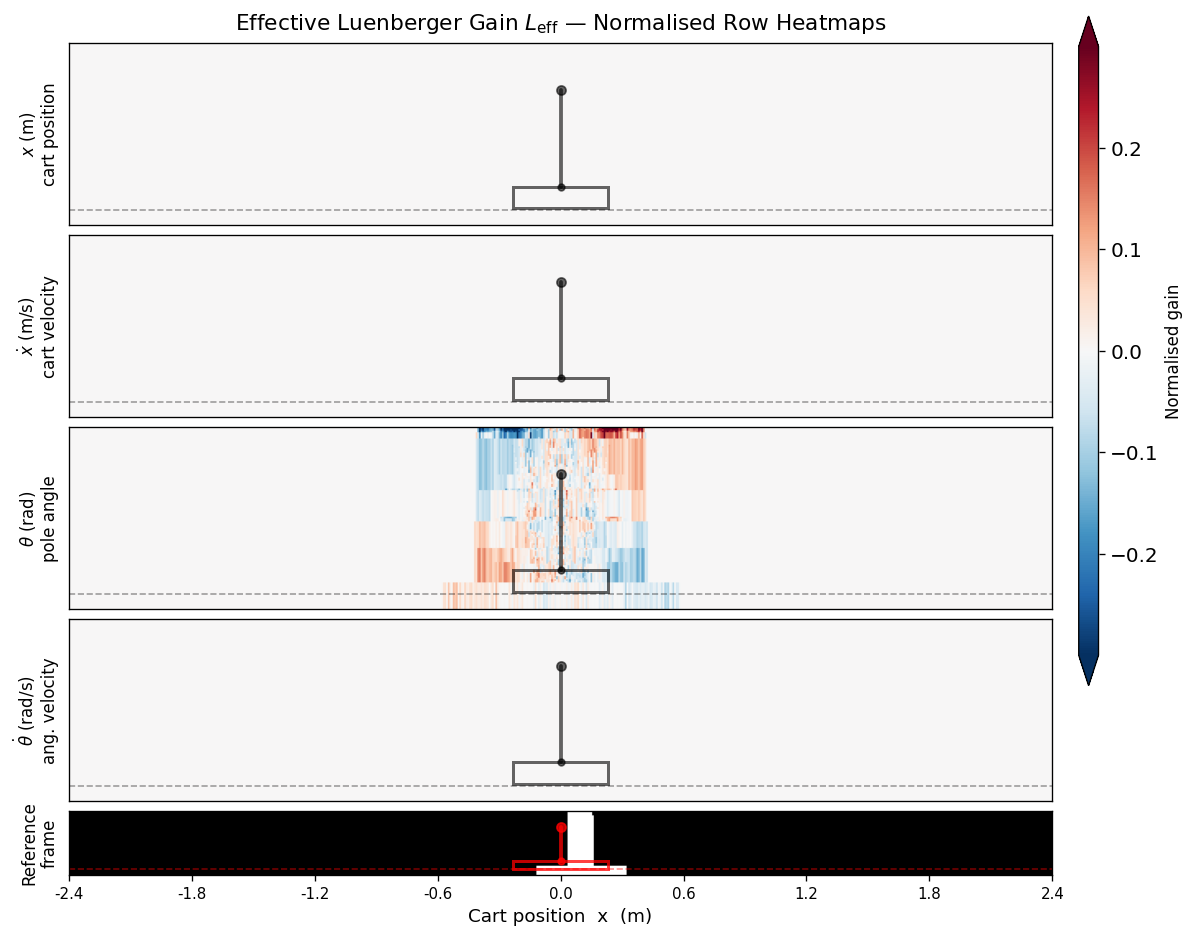

In [16]:
# ── Plot Figure 2 ─────────────────────────────────────────────────────────────
state_labels = [
    r"$x$ (m)" + "\ncart position",
    r"$\dot{x}$ (m/s)" + "\ncart velocity",
    r"$\theta$ (rad)" + "\npole angle",
    r"$\dot{\theta}$ (rad/s)" + "\nang. velocity",
]

# x-axis tick positions and labels (pixel columns → metres)
x_m_vals  = np.array([-2.4, -1.8, -1.2, -0.6, 0.0, 0.6, 1.2, 1.8, 2.4])
x_px_vals = (x_m_vals + 2.4) / 4.8 * frame_w

n_rows = 5  # 4 heatmaps + 1 reference frame
height_ratios = [1, 1, 1, 1, 0.35]

fig2 = plt.figure(figsize=(11, 9.0))
gs2  = GridSpec(n_rows, 1, figure=fig2, hspace=0.06,
                height_ratios=height_ratios)
axes_hm = [fig2.add_subplot(gs2[i, 0]) for i in range(4)]
ax_ref  = fig2.add_subplot(gs2[4, 0])

# Clip at ±0.3 of the normalised range to saturate the active (θ) row
cmap_hm = "RdBu_r"
norm_hm = TwoSlopeNorm(vmin=-0.3, vcenter=0.0, vmax=0.3)

im_last = None
for i, (ax, label) in enumerate(zip(axes_hm, state_labels)):
    im = ax.imshow(L_norm[i], cmap=cmap_hm, norm=norm_hm,
                   aspect="auto", origin="upper",
                   extent=[0, frame_w, frame_h, 0])
    draw_cartpole(ax, theta_deg=0.0, color="black", alpha=0.6)
    ax.set_ylabel(label, fontsize=10, labelpad=6)
    ax.set_yticks([])
    ax.set_xticks([])
    im_last = im
    if i == 0:
        ax.set_title(
            r"Effective Luenberger Gain $L_{\mathrm{eff}}$ — Normalised Row Heatmaps",
            fontsize=13, pad=8
        )

# Shared colourbar
fig2.subplots_adjust(right=0.87)
cbar_ax = fig2.add_axes([0.89, 0.285, 0.015, 0.62])
cb = fig2.colorbar(im_last, cax=cbar_ax, extend="both")
cb.set_label("Normalised gain", fontsize=10)

# Reference binary frame
ax_ref.imshow(ref_img, cmap="gray", aspect="auto", origin="upper",
              extent=[0, frame_w, frame_h, 0])
draw_cartpole(ax_ref, theta_deg=0.0, color="red", alpha=0.75)
ax_ref.set_ylabel("Reference\nframe", fontsize=10, labelpad=6)
ax_ref.set_yticks([])
ax_ref.set_xticks(x_px_vals)
ax_ref.set_xticklabels([f"{v:.1f}" for v in x_m_vals], fontsize=9)
ax_ref.set_xlabel("Cart position  x  (m)", fontsize=11)

plt.savefig(SCRIPT_DIR / "fig2_L_heatmap.pdf", bbox_inches="tight")
plt.savefig(SCRIPT_DIR / "fig2_L_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Figure 3 — Time Histories

A single student rollout starting from θ₀ = 8°.  
Each state subplot shows the **true state** (solid) and the **student's estimate** (dashed).  
The control subplot compares the **student's command** (−K x̂, solid) against the **teacher-anticipated command** (−K x, dashed) — the ideal control given perfect state knowledge.

In [17]:
# ── Student rollout function ───────────────────────────────────────────────────
def run_student_rollout(obs_dict, true_params, initial_state, steps):
    """Simulate student controller; return (t, x_true, x_hat, u_student, u_teacher)."""
    A_L  = np.asarray(obs_dict["A_L"])
    B_L  = np.asarray(obs_dict["B_L"]).reshape(4, 1)
    L_g  = np.asarray(obs_dict["L"])
    d    = np.asarray(obs_dict["d"])
    gain = np.asarray(obs_dict["teacher_gain"]).reshape(1, 4)
    tc   = obs_dict.get("theta_pixel_coefficients")
    tb   = float(obs_dict.get("theta_pixel_bias") or 0.0)
    tw   = float(obs_dict.get("theta_pixel_blend_weight", 0.0))
    fw   = int(obs_dict["frame_width_px"])
    fh   = int(obs_dict["frame_height_px"])

    env   = create_cartpole_env("rgb_array", true_params)
    set_cartpole_state(env, initial_state, true_params)
    x_hat = initial_state.copy()

    t_list, xt_list, xh_list, us_list, ut_list = [], [], [], [], []

    for step in range(steps):
        u_s             = float(-(gain @ x_hat)[0])
        state, done, st = step_cartpole_env(env, u_s, true_params)
        rendered        = env.render()
        binary          = extract_binary_pole_frame(np.asarray(rendered), None, None)
        binary          = pad_binary_frame_to_shape(binary, fw, fh)
        y               = binary.astype(np.float64).reshape(-1) / 255.0
        cmd             = float(st["commanded_control_force_n"])
        xh_next         = A_L @ x_hat + B_L[:, 0] * cmd + L_g @ y + d
        if tc is not None:
            tp          = float(tc @ y + tb)
            xh_next[2]  = (1 - tw) * xh_next[2] + tw * tp
        x_hat = xh_next

        u_t = float(-(K_teacher @ state)[0])  # teacher anticipated control
        t_list.append((step + 1) * true_params.sample_time_s)
        xt_list.append(state.copy())
        xh_list.append(x_hat.copy())
        us_list.append(u_s)
        ut_list.append(u_t)

        if done:
            print(f"  Terminated at step {step+1} ({t_list[-1]:.2f} s)")
            break

    env.close()
    return (
        np.array(t_list),
        np.array(xt_list),
        np.array(xh_list),
        np.array(us_list),
        np.array(ut_list),
    )

print("Rollout function defined.")

Rollout function defined.


In [18]:
# ── Run or load rollout ────────────────────────────────────────────────────────
obs_policy = load_observer_policy(OBSERVER_JSON)

if FIG3_ROLLOUT_CACHE.exists():
    print(f"Loading rollout cache from {FIG3_ROLLOUT_CACHE.name}")
    rc       = np.load(FIG3_ROLLOUT_CACHE)
    t_arr    = rc["t"]
    xt_arr   = rc["x_true"]
    xh_arr   = rc["x_hat"]
    us_arr   = rc["u_student"]
    ut_arr   = rc["u_teacher"]
else:
    print(f"Running student rollout (θ₀={FIG3_THETA0_DEG}°, {FIG3_STEPS} steps) …")
    x0 = np.array([0.0, 0.0, math.radians(FIG3_THETA0_DEG), 0.0])
    t_arr, xt_arr, xh_arr, us_arr, ut_arr = run_student_rollout(
        obs_policy, TRUE_PARAMS, x0, FIG3_STEPS
    )
    np.savez(FIG3_ROLLOUT_CACHE, t=t_arr, x_true=xt_arr, x_hat=xh_arr,
             u_student=us_arr, u_teacher=ut_arr)
    print(f"Rollout saved ({len(t_arr)} steps, {t_arr[-1]:.2f} s)")

print(f"Duration  : {t_arr[-1]:.2f} s  ({len(t_arr)} steps)")
print(f"Final ‖x‖ : {np.linalg.norm(xt_arr[-1]):.4f}")
print(f"Final ‖x̂‖ : {np.linalg.norm(xh_arr[-1]):.4f}")

Loading rollout cache from fig3_rollout_cache.npz
Duration  : 5.00 s  (300 steps)
Final ‖x‖ : 0.4283
Final ‖x̂‖ : 0.4098


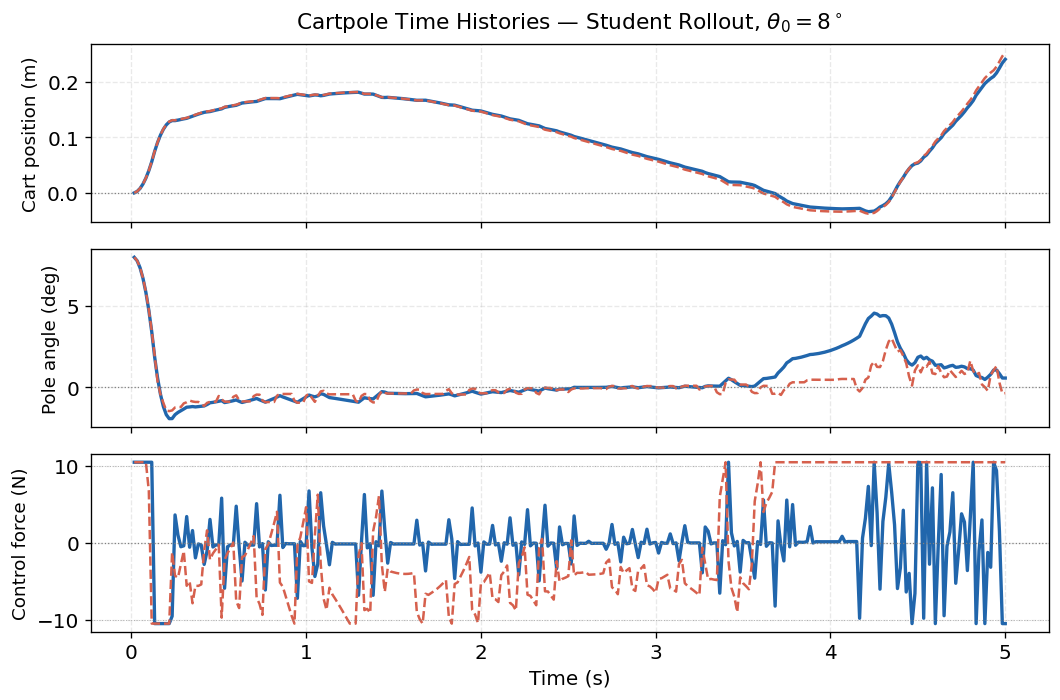

In [19]:
# ── Plot Figure 3 ─────────────────────────────────────────────────────────────
C_TRUE = "#2166ac"   # blue  — true state / student command
C_EST  = "#d6604d"   # red   — student estimate / teacher anticipated

fig3, axes3 = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
fig3.subplots_adjust(hspace=0.07)

state_cfg = [
    (xt_arr[:, 0],             xh_arr[:, 0],             "Cart position (m)"),
    (np.degrees(xt_arr[:, 2]), np.degrees(xh_arr[:, 2]), "Pole angle (deg)"),
]

for i, (x_true_col, x_hat_col, ylabel) in enumerate(state_cfg):
    ax = axes3[i]
    ax.plot(t_arr, x_true_col, color=C_TRUE, lw=2.0)
    ax.plot(t_arr, x_hat_col,  color=C_EST,  lw=1.5, ls="--")
    ax.axhline(0, color="gray", lw=0.75, ls=":")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, alpha=0.28, ls="--")
    if i == 0:
        ax.set_title(
            f"Cartpole Time Histories — Student Rollout, "
            f"$\\theta_0 = {FIG3_THETA0_DEG:.0f}^\\circ$",
            fontsize=13, pad=9
        )

# Control panel
ax_u = axes3[2]
ax_u.plot(t_arr, np.clip(us_arr, -10.5, 10.5), color=C_TRUE, lw=2.0,
          label=r"Student $u = -K\hat{x}$")
ax_u.plot(t_arr, np.clip(ut_arr, -10.5, 10.5), color=C_EST,  lw=1.5, ls="--",
          label=r"Teacher anticipated $u = -Kx$")
ax_u.axhline( 0,  color="gray", lw=0.75, ls=":")
ax_u.axhline( 10, color="#888", lw=0.6,  ls=":", alpha=0.6)
ax_u.axhline(-10, color="#888", lw=0.6,  ls=":", alpha=0.6)
ax_u.set_ylabel("Control force (N)", fontsize=11)
ax_u.set_xlabel("Time (s)", fontsize=12)
ax_u.grid(True, alpha=0.28, ls="--")

plt.tight_layout()
plt.savefig(SCRIPT_DIR / "fig3_time_histories.pdf", bbox_inches="tight")
plt.savefig(SCRIPT_DIR / "fig3_time_histories.png", dpi=150, bbox_inches="tight")
plt.show()